In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
import os
print(os.getcwd())

c:\Users\VENKATA LAKSHMI\Documents\climate-change-project


In [13]:
import os
print(os.listdir())

['climate_analysis.ipynb', 'GlobalLandTemperaturesByCity.csv']


In [14]:
df = pd.read_csv("GlobalLandTemperaturesByCity.csv")
df.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1743-11-01,6.068,1.737,Århus,Denmark,57.05N,10.33E
1,1743-12-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
2,1744-01-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
3,1744-02-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
4,1744-03-01,NaN,NaN,Århus,Denmark,57.05N,10.33E


In [15]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8599212 entries, 0 to 8599211
Data columns (total 7 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   dt                             object 
 1   AverageTemperature             float64
 2   AverageTemperatureUncertainty  float64
 3   City                           object 
 4   Country                        object 
 5   Latitude                       object 
 6   Longitude                      object 
dtypes: float64(2), object(5)
memory usage: 459.2+ MB


,AverageTemperature,AverageTemperatureUncertainty
count,8.235082e+06,8.235082e+06
mean,1.672743e+01,1.028575e+00
std,1.035344e+01,1.129733e+00
min,-4.270400e+01,3.400000e-02
25%,1.029900e+01,3.370000e-01
50%,1.883100e+01,5.910000e-01
75%,2.521000e+01,1.349000e+00
max,3.965100e+01,1.539600e+01


In [16]:
df['dt'] = pd.to_datetime(df['dt'])
df['year'] = df['dt'].dt.year

In [17]:
df = df.dropna()

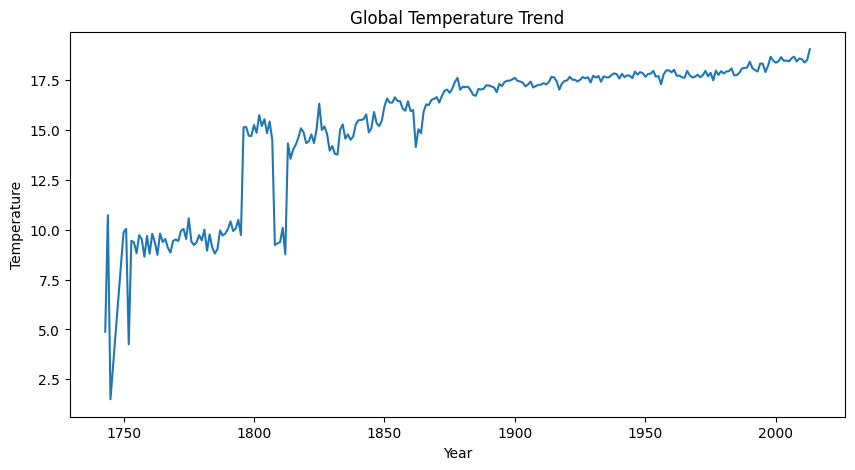

In [18]:
global_temp = df.groupby('year')['AverageTemperature'].mean()

plt.figure(figsize=(10,5))
plt.plot(global_temp)
plt.title("Global Temperature Trend")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()

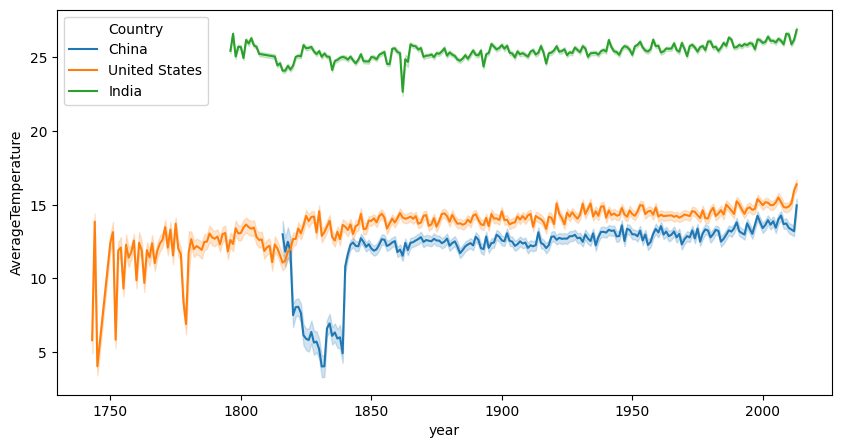

In [19]:
countries = ['India', 'United States', 'China']
data = df[df['Country'].isin(countries)]

plt.figure(figsize=(10,5))
sns.lineplot(data=data, x='year', y='AverageTemperature', hue='Country')
plt.show()

<Axes: xlabel='AverageTemperature', ylabel='Count'>

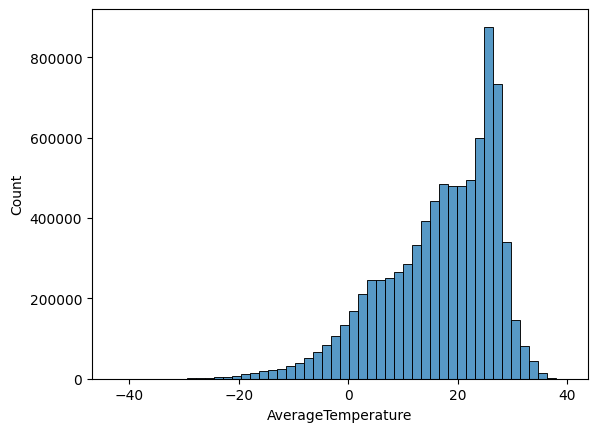

In [20]:
sns.histplot(df['AverageTemperature'], bins=50)

<Axes: xlabel='Country', ylabel='Country'>

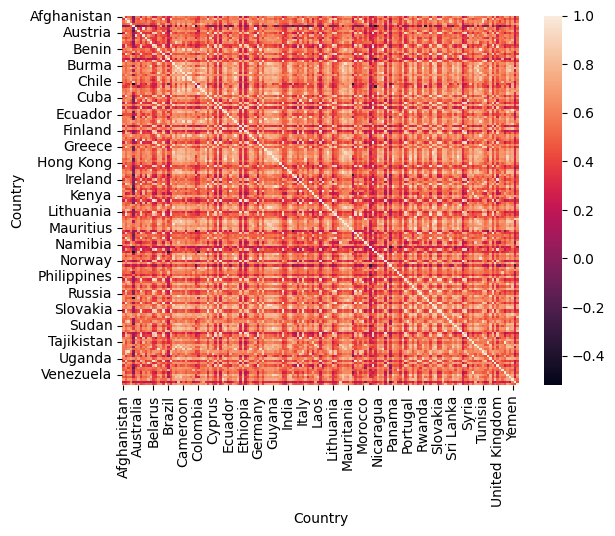

In [21]:
pivot = df.pivot_table(values='AverageTemperature', index='year', columns='Country')
sns.heatmap(pivot.corr())

In [22]:
model_df = global_temp.reset_index()

In [23]:
from sklearn.model_selection import train_test_split

X = model_df[['year']]
y = model_df['AverageTemperature']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [24]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
from sklearn.metrics import mean_squared_error

y_pred = model.predict(X_test)
print(mean_squared_error(y_test, y_pred))

4.597686595274775


In [26]:
future_years = pd.DataFrame({'year': [2030, 2040, 2050]})
predictions = model.predict(future_years)

print(predictions)

[20.99145354 21.36305699 21.73466043]


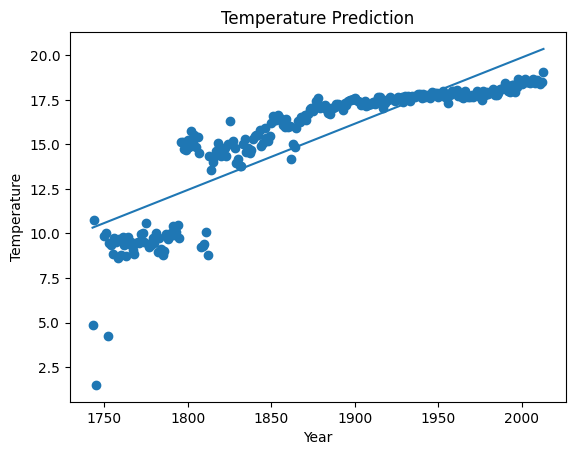

In [27]:
plt.scatter(X, y)
plt.plot(X, model.predict(X))
plt.title("Temperature Prediction")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()

## 📊 Insights & Conclusion

- The analysis shows a clear increase in global temperature over the years.
- This indicates a strong global warming trend.
- Country and city-level analysis also reflect similar rising patterns.
- The machine learning model predicts that temperatures will continue to rise in the future.
- These results highlight the measurable impact of climate change.

## 🌍 Final Conclusion

Climate change is real, data-driven, and continuously impacting global temperatures. Immediate action is necessary to control further environmental damage.